#### Import Libraries


In [183]:
import pandas as pd

#### Load Dataset


In [184]:
# Load the Excel dataset.
df = pd.read_excel("flight_price.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


#### Initial Data Inspection


In [185]:
# Display column names, non-null counts, and data types.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.8 MB


In [186]:
# Count missing values in each column.
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [187]:
# Review the available airline categories.
df["Airline"].unique()

<ArrowStringArray>
[                           'IndiGo',                         'Air India',
                       'Jet Airways',                          'SpiceJet',
                 'Multiple carriers',                             'GoAir',
                           'Vistara',                          'Air Asia',
           'Vistara Premium economy',              'Jet Airways Business',
 'Multiple carriers Premium economy',                            'Trujet']
Length: 12, dtype: str

#### Feature Engineering


#### Date Features


In [189]:
df["Date"] = df["Date_of_Journey"].str.split("/").str[0]
df["Month"] = df["Date_of_Journey"].str.split("/").str[1]
df["Year"] = df["Date_of_Journey"].str.split("/").str[2]
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,05,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,06,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,05,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,01,03,2019


In [190]:
# Convert extracted date parts from strings to integers.

df["Date"] = df["Date"].astype(int)
df["Month"] = df["Month"].astype(int)
df["Year"] = df["Year"].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
 11  Date             10683 non-null  int64
 12  Month            10683 non-null  int64
 13  Year             10683 non-null  int64
dtypes: int64(4), str(10)
memory usage: 2.0 MB


In [191]:
# Drop the original journey date after creating Date, Month, and Year.
df.drop(["Date_of_Journey"], axis=1, inplace=True)

In [192]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


#### Arrival Time Features


In [193]:
# Keep only the time part when Arrival_Time also contains a date.
df["Arrival_Time"] = df["Arrival_Time"].apply(lambda x: x.split(" ")[0])
# Split arrival time into hour and minute features.
df["Arrival_Time_hour"] = df["Arrival_Time"].str.split(":").str[0]
df["Arrival_Time_minute"] = df["Arrival_Time"].str.split(":").str[1]
# Drop the original Arrival_Time column after extracting features.
df.drop(["Arrival_Time"], axis=1, inplace=True)
# Check that the extracted arrival time parts can be converted to integers.
df["Arrival_Time_hour"].astype(int)
df["Arrival_Time_minute"].astype(int)
df.head()

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897,24,3,2019,01,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662,1,5,2019,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,19h,2 stops,No info,13882,9,6,2019,04,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,5h 25m,1 stop,No info,6218,12,5,2019,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,4h 45m,1 stop,No info,13302,1,3,2019,21,35


#### Departure Time Features


In [194]:
# Split departure time into hour and minute features.
df["Dep_Time_hour"] = df["Dep_Time"].str.split(":").str[0]
df["Dep_Time_minute"] = df["Dep_Time"].str.split(":").str[1]
# Drop the original Dep_Time column after extracting features.
df.drop(["Dep_Time"], axis=1, inplace=True)
# Check that the extracted departure time parts can be converted to integers.
df["Dep_Time_hour"].astype(int)
df["Dep_Time_minute"].astype(int)
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,01,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,13,15,05,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,04,25,09,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,23,30,18,05
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,21,35,16,50


#### Duration Features


In [195]:
# Extract duration hours; rows without hours are filled with 0.
df["Duration_hour"] = (
    df["Duration"].str.extract(r"(\d+)h", expand=False).fillna(0).astype(int)
)
# Extract duration minutes; rows without minutes are filled with 0.
df["Duration_minute"] = (
    df["Duration"].str.extract(r"(\d+)m", expand=False).fillna(0).astype(int)
)

# Drop the original Duration column after extracting numeric duration features.
df.drop(["Duration"], axis=1, inplace=True)

df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute,Duration_hour,Duration_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,01,10,22,20,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,13,15,05,50,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,2019,04,25,09,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,2019,23,30,18,05,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,2019,21,35,16,50,4,45


#### Total Stops Encoding


In [196]:
# Review Total_Stops categories before cleaning.
df["Total_Stops"].unique()

<ArrowStringArray>
['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops']
Length: 6, dtype: str

In [197]:
# Count missing values in Total_Stops.
df["Total_Stops"].isnull().sum()

np.int64(1)

In [198]:
# Fill missing Total_Stops values using the most frequent category.
mode_impute = df["Total_Stops"].mode()
df["Total_Stops"] = df["Total_Stops"].fillna(mode_impute[0])

In [199]:
df["Total_Stops"].unique()
# Encode Total_Stops as an ordered categorical feature.
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    categories=[["non-stop", "2 stops", "1 stop", "3 stops", "4 stops"]]
)
encoded_total_stops = encoder.fit_transform(df[["Total_Stops"]])
encoded_total_stops

array([[0.],
       [1.],
       [1.],
       ...,
       [0.],
       [0.],
       [1.]], shape=(10683, 1))

In [200]:
# Save the encoded Total_Stops values back to the dataframe.
df["Total_Stops"] = encoded_total_stops
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute,Duration_hour,Duration_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,0.0,No info,3897,24,3,2019,01,10,22,20,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,1.0,No info,7662,1,5,2019,13,15,05,50,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1.0,No info,13882,9,6,2019,04,25,09,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,2.0,No info,6218,12,5,2019,23,30,18,05,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,2.0,No info,13302,1,3,2019,21,35,16,50,4,45


#### Route Missing Value Handling


In [201]:
# Count missing values in Route.
df["Route"].isnull().sum()

np.int64(1)

In [202]:
# Fill the missing Route value using the most frequent route.
df["Route"] = df["Route"].fillna(df["Route"].mode()[0])

In [203]:
# Preview Route after imputation.
df["Route"].head()

0                BLR → DEL
1    CCU → IXR → BBI → BLR
2    DEL → LKO → BOM → COK
3          CCU → NAG → BLR
4          BLR → NAG → DEL
Name: Route, dtype: str

#### Nominal Categorical Encoding

Airline, Source, Destination, and Additional_Info are nominal categorical features, so one-hot encoding is appropriate.


In [205]:
# Review airline categories before one-hot encoding.
df["Airline"].unique()

<ArrowStringArray>
[                           'IndiGo',                         'Air India',
                       'Jet Airways',                          'SpiceJet',
                 'Multiple carriers',                             'GoAir',
                           'Vistara',                          'Air Asia',
           'Vistara Premium economy',              'Jet Airways Business',
 'Multiple carriers Premium economy',                            'Trujet']
Length: 12, dtype: str

In [206]:
from sklearn.preprocessing import OneHotEncoder

# Create one-hot encoded columns for Airline.
airline_ohe_encoder = OneHotEncoder()
encoded_airline = airline_ohe_encoder.fit_transform(df[["Airline"]]).toarray()
encoded_airline

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(10683, 12))

In [207]:
# Convert the encoded Airline array into a dataframe with readable column names.
encoded_df = pd.DataFrame(
    encoded_airline, columns=airline_ohe_encoder.get_feature_names_out()
)
encoded_df.head()

,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [208]:
# Combine the one-hot encoded Airline columns with the main dataframe.
df = pd.concat([df, encoded_df], axis=1)
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Date,Month,Year,...,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,IndiGo,Banglore,New Delhi,BLR → DEL,0.0,No info,3897,24,3,2019,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,1.0,No info,7662,1,5,2019,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1.0,No info,13882,9,6,2019,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,2.0,No info,6218,12,5,2019,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,2.0,No info,13302,1,3,2019,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Basic Price Analysis


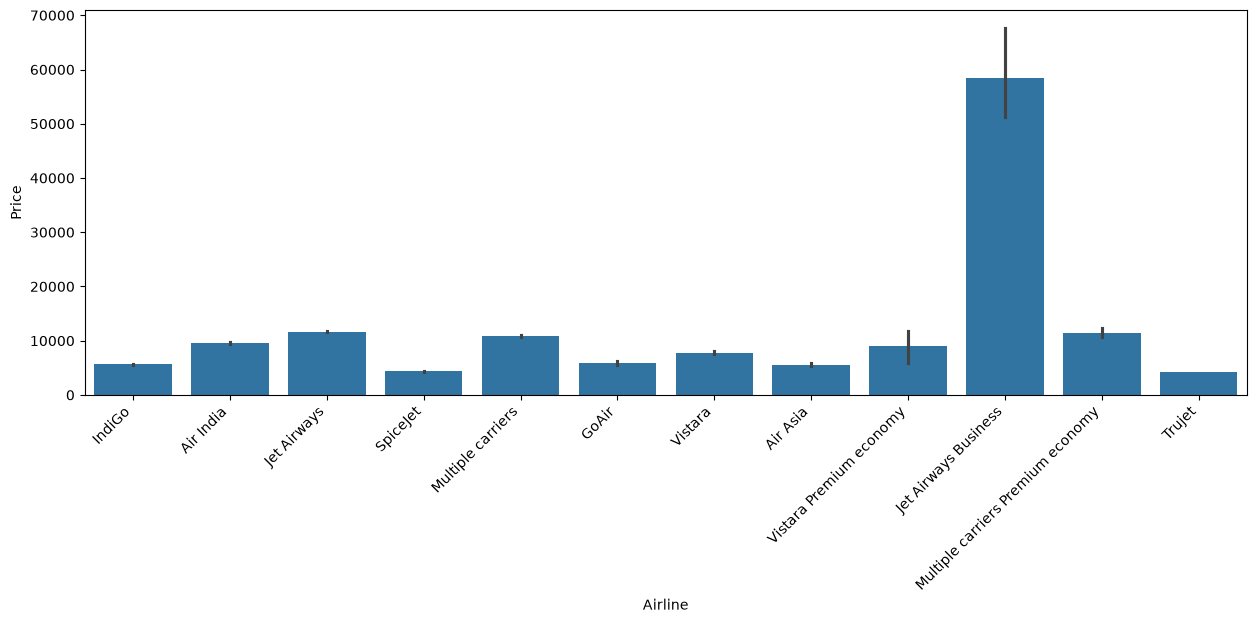

In [218]:
# Compare ticket price across airlines.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

sns.barplot(x="Airline", y="Price", data=df)
plt.xticks(rotation=45, ha="right")  # Rotate labels
plt.show()